Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model for X1: Y = 5.9279 + -2.0383*X1 (Final Loss: 0.9850)


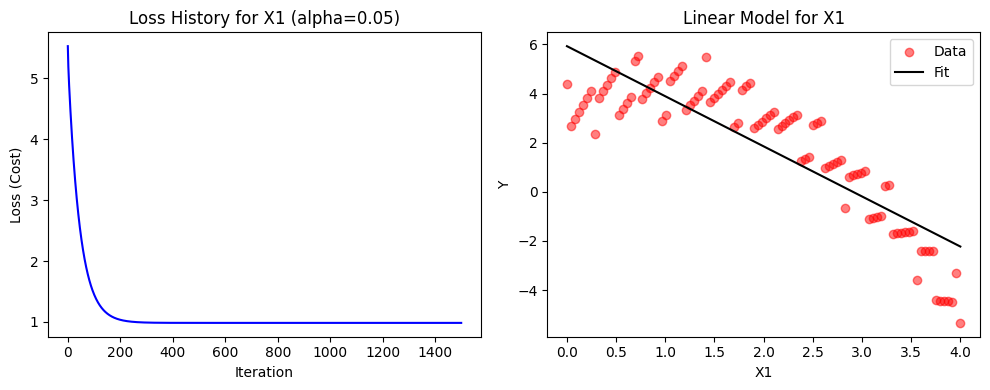

Model for X2: Y = 0.7361 + 0.5576*X2 (Final Loss: 3.5994)


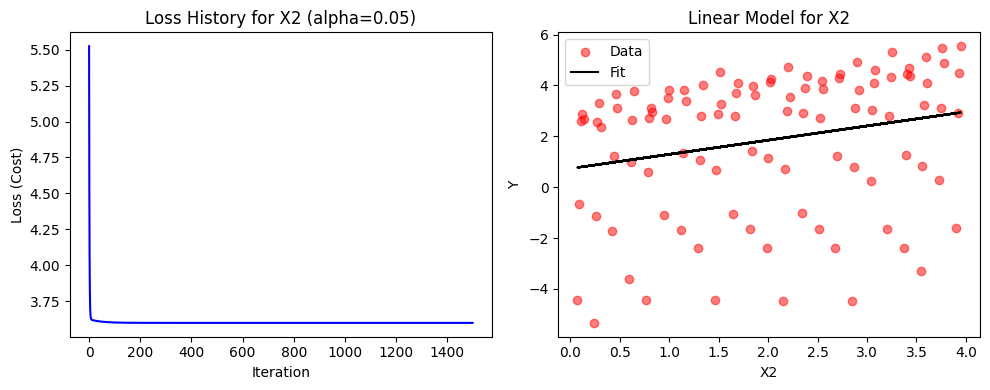

Model for X3: Y = 2.8714 + -0.5205*X3 (Final Loss: 3.6295)


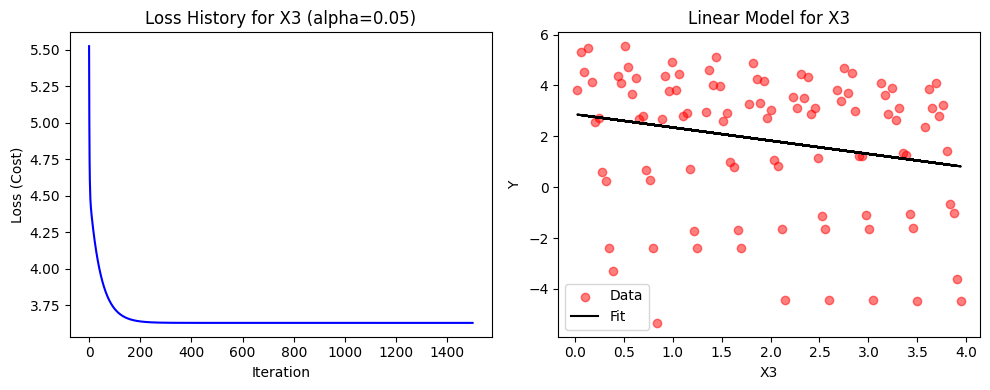

In [3]:
#Problem 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
file_path = '/content/drive/My Drive/Intro to ML/Datasets/D3.csv'
df = pd.read_csv(file_path)
df.head()

X = df.iloc[:, :3].values
Y = df.iloc[:, 3].values
m = len(Y)

#Set learning rate, I chose 0.05 because it's in the middle of 0.1:0.01
alpha = 0.05
iterations = 1500

models_p1 = {}

for i in range(3):
    theta_0 = 0.0
    theta_1 = 0.0
    x_i = X[:, i]
    cost_history = []

    for _ in range(iterations):
        predictions = theta_0 + theta_1 * x_i
        errors = predictions - Y

        # Gradient descent updates
        theta_0 -= (alpha / m) * np.sum(errors)
        theta_1 -= (alpha / m) * np.sum(errors * x_i)

        # Mean Squared Error cost
        cost = (1 / (2 * m)) * np.sum(errors ** 2)
        cost_history.append(cost)

    models_p1[f'X{i+1}'] = {'theta_0': theta_0, 'theta_1': theta_1, 'cost': cost_history[-1]}

    print(f"Model for X{i+1}: Y = {theta_0:.4f} + {theta_1:.4f}*X{i+1} (Final Loss: {cost_history[-1]:.4f})")

    # Plotting Loss over iterations
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(cost_history, color='blue')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (Cost)')
    plt.title(f'Loss History for X{i+1} (alpha={alpha})')

    # Plotting Regression Line
    plt.subplot(1, 2, 2)
    plt.scatter(x_i, Y, color='red', alpha=0.5, label='Data')
    plt.plot(x_i, theta_0 + theta_1 * x_i, color='black', label='Fit')
    plt.xlabel(f'X{i+1}')
    plt.ylabel('Y')
    plt.title(f'Linear Model for X{i+1}')
    plt.legend()
    plt.tight_layout()
    plt.show()

Best Multivariate Model: Y = 5.3113 + -2.0033*X1 + 0.5330*X2 + -0.2652*X3
Final Loss: 0.7385


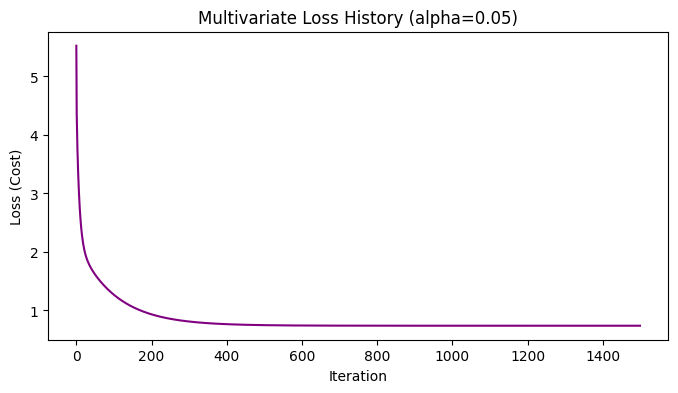

Prediction for X=[1 1 1]: Y = 3.5758
Prediction for X=[2 0 4]: Y = 0.2439
Prediction for X=[3 2 1]: Y = 0.1022


In [4]:
# Prepare feature matrix with intercept; then initialize parameters to zero
X_b = np.c_[np.ones((m, 1)), X]
theta = np.zeros(4)

alpha_multi = 0.05
iterations_multi = 1500
cost_history_multi = []

for _ in range(iterations_multi):
    predictions = X_b.dot(theta)
    errors = predictions - Y

    # Vectorized gradient update
    theta -= (alpha_multi / m) * (X_b.T.dot(errors))

    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    cost_history_multi.append(cost)

print(f"Best Multivariate Model: Y = {theta[0]:.4f} + {theta[1]:.4f}*X1 + {theta[2]:.4f}*X2 + {theta[3]:.4f}*X3")
print(f"Final Loss: {cost_history_multi[-1]:.4f}")

# Plot Loss over iterations
plt.figure(figsize=(8, 4))
plt.plot(cost_history_multi, color='purple')
plt.xlabel('Iteration')
plt.ylabel('Loss (Cost)')
plt.title(f'Multivariate Loss History (alpha={alpha_multi})')
plt.show()

# Predictions for new data points
new_points = np.array([
    [1, 1, 1],
    [2, 0, 4],
    [3, 2, 1]
])

# Add intercept column to new points
new_points_b = np.c_[np.ones((new_points.shape[0], 1)), new_points]
predictions_new = new_points_b.dot(theta)

for pt, pred in zip(new_points, predictions_new):
    print(f"Prediction for X={pt}: Y = {pred:.4f}")